In [1]:
import matplotlib.pyplot as plt
import numpy as np
from bat_class import BatOsc, bat_from_pkl, Ball, ball_from_pkl
from plot_osc import plot_batsol_heatmap

In [2]:
#path names
bats_results_path = '/Users/navawolfish/Desktop/baseball/AlanProject/results/standard/'
batt_results_path = '/Users/navawolfish/Desktop/baseball/AlanProject/results/torpedo/'
fname = 'bat_impact_{}.pkl'


In [3]:
#pick random idx
np.random.seed(42)
idx = np.random.randint(50, 83)
print(f'random idx: {idx}')

#load data
#standard
bat_standard = bat_from_pkl(bats_results_path + fname.format(idx))
ball_standard = bat_standard.ball

#torpedo
bat_torpedo = bat_from_pkl(batt_results_path + fname.format(idx))
ball_torpedo = bat_torpedo.ball

random idx: 78


In [4]:
#reset solution
bat_standard.reset()
ball_standard.reset()

bat_torpedo.reset()
ball_torpedo.reset()

In [5]:
#reintegrate for longer time to get more data for fourier analysis
dt = 1e-4
t_final = 0.05
tspan = (0, t_final)
t_eval = np.arange(0, t_final, dt)

bat_standard.set_initial_conditions(np.zeros(4 * bat_standard.N))
bat_torpedo.set_initial_conditions(np.zeros(4 * bat_torpedo.N))

#simulate for standard bat
print("Simulating standard bat...")
sol_standard = bat_standard.integrate_with_ball(tspan, ball_standard, idx, t_eval = t_eval)
#simulate for torpedo bat
print("Simulating torpedo bat...")
sol_torpedo = bat_torpedo.integrate_with_ball(tspan, ball_torpedo, idx, t_eval = t_eval)

Simulating standard bat...
Simulating torpedo bat...


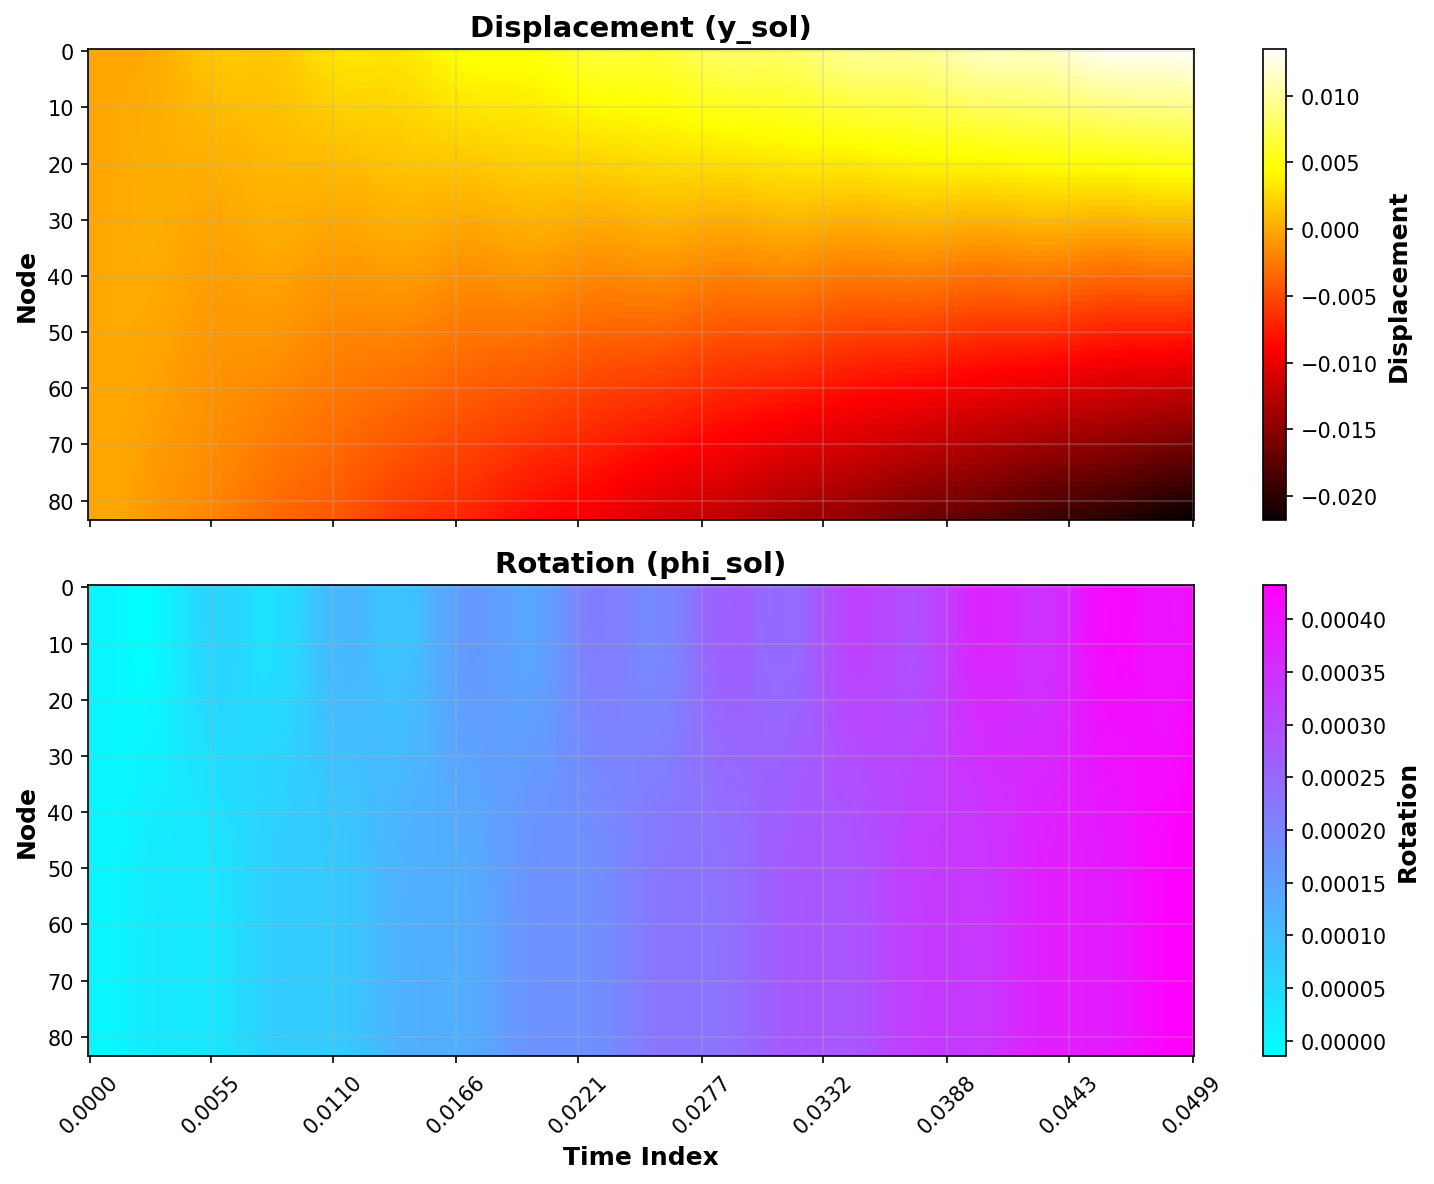

In [6]:
#plot displacement of bat over time
plot_batsol_heatmap(bat_standard)
plt.show()

In [7]:
# fourier 
bat_fft = np.fft.fft(bat_standard.y_sol, axis=1) #take fft along time axis
ntime = len(bat_standard.t) 
freqs = np.fft.fftfreq(ntime, d= bat_standard.t[1] - bat_standard.t[0]) #frequency bins corresponding to FFT components

# Compute amplitude spectrum
amplitude = np.abs(bat_fft[:, 0:ntime//2])
freqs_pos = freqs[0:ntime//2] #positive frequencies


# Average amplitude across all nodes
mean_amplitude = amplitude.mean(axis=0)


freqs_pos_mask = freqs_pos < 1000 #only look at frequencies below 1000 Hz
new_freqs = freqs_pos[freqs_pos_mask]
mean_amplitude = mean_amplitude[freqs_pos_mask]

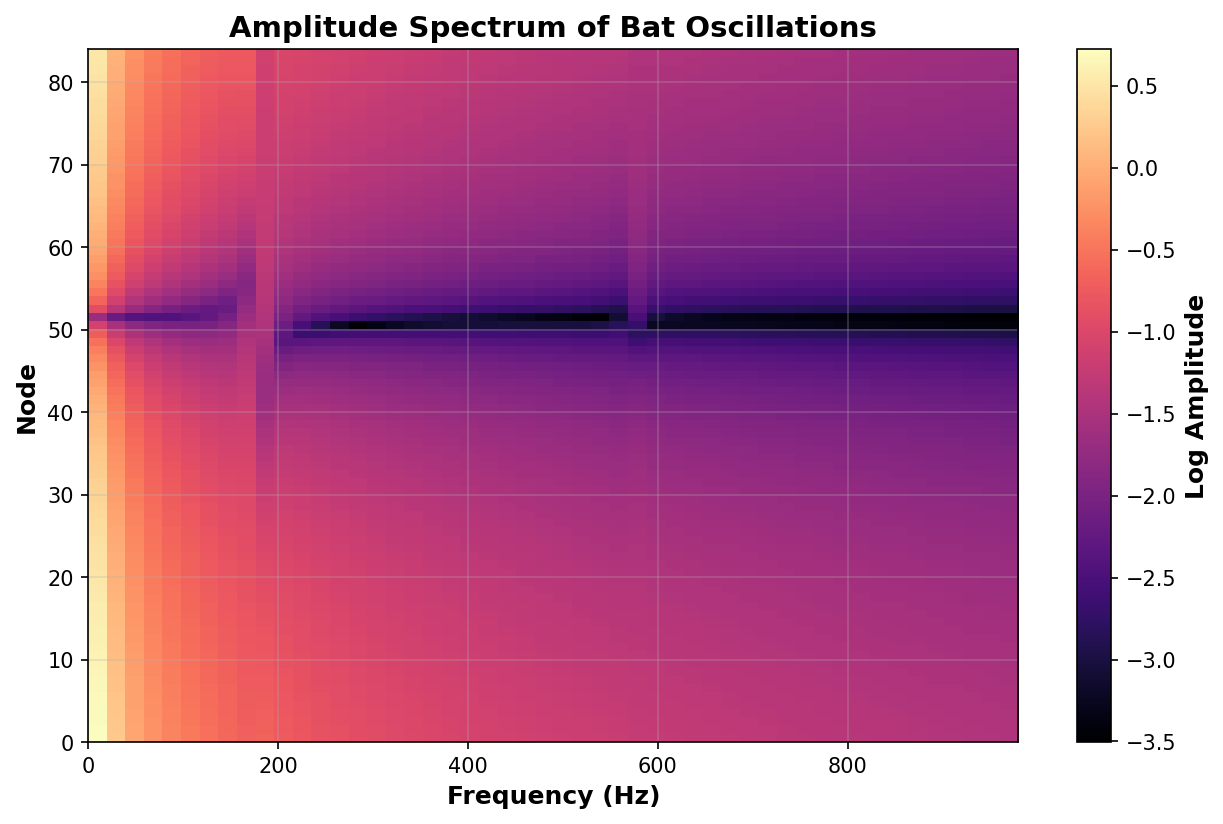

In [8]:
# Plot the fft
cmap = plt.get_cmap('magma').colors[:len(amplitude)] # get a subset of the colormap for the number of frequencies

log_amp = np.log10(amplitude + 1e-10) # add small value to avoid log(0)
plt.imshow(log_amp[:, freqs_pos_mask], extent=(new_freqs[0], new_freqs[-1], 0, amplitude.shape[0]), aspect='auto', cmap='magma')
plt.colorbar(label='Log Amplitude')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Node')
plt.title('Amplitude Spectrum of Bat Oscillations')
plt.show()

In [9]:
#find peaks in the residuals 
from scipy.signal import find_peaks
peaks, _ = find_peaks(mean_amplitude) # only consider peaks with height > 5%
print("Significant peaks in spectrum at frequencies (Hz):")
for peak in peaks:
    print(f"{new_freqs[peak]:.2f} Hz with amplitude {mean_amplitude[peak]:.4f}")

centroids = []
print("Centroid frequencies of significant peaks (Hz):")
for peak in peaks:
    # Define a window around the peak for centroid calculation
    window = 5  # number of points on each side
    left = max(peak - window, 0)
    right = min(peak + window + 1, len(mean_amplitude))
    amp_window = mean_amplitude[left:right]
    freq_window = new_freqs[left:right]
    # Centroid calculation (center of mass)
    centroid = np.sum(freq_window * amp_window) / np.sum(amp_window)
    centroids.append(centroid)
    print(f"Peak at {new_freqs[peak]:.2f} Hz, centroid: {centroid:.2f} Hz, amplitude: {mean_amplitude[peak]:.4f}")
centroids = np.array(centroids)

Significant peaks in spectrum at frequencies (Hz):
580.00 Hz with amplitude 0.0270
Centroid frequencies of significant peaks (Hz):
Peak at 580.00 Hz, centroid: 573.31 Hz, amplitude: 0.0270


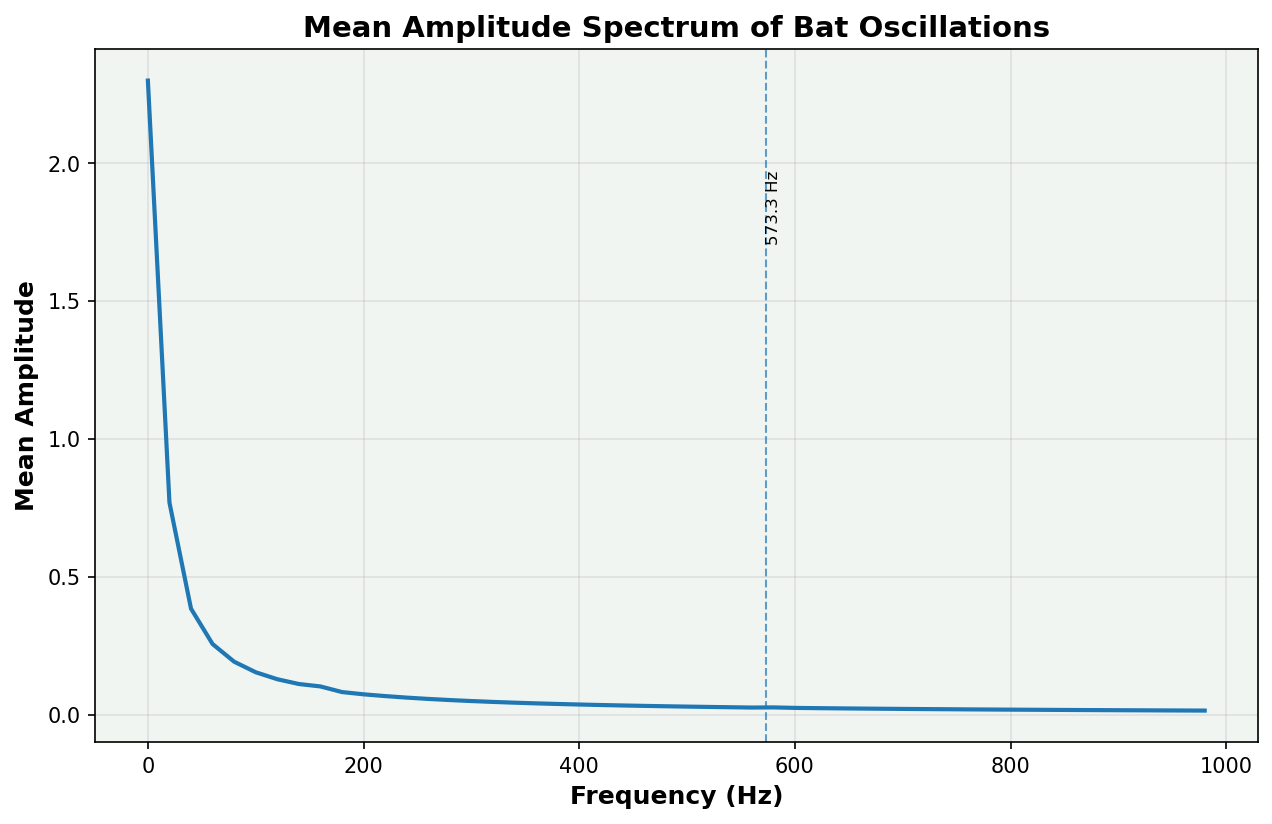

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(new_freqs, mean_amplitude, label='Mean Amplitude Spectrum')
for centroid in centroids:
    plt.axvline(x=centroid,linestyle='--', alpha=0.7, label=f'Centroid: {centroid:.2f} Hz', linewidth = 1)
    plt.text(centroid, max(mean_amplitude)*0.8, f'{centroid:.1f} Hz', rotation=90, verticalalignment='center', fontsize=8)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Mean Amplitude')
plt.title('Mean Amplitude Spectrum of Bat Oscillations')
plt.show()